In [5]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [6]:
#functions



def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group


def global_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

def lat_bands_gt(data, datadata, minlat,maxlat, detrend = False):
    #select region
    data = data.sel(lat = slice(maxlat,minlat))
    datadata = datadata.sel(lat = slice(maxlat,minlat))
    #calculate anomaly
    data_weights = build_weights(data, datadata)
    data_glbmean = global_mean(data, datadata, data_weights)
    data_glbanom = anomaly(data_glbmean, data_weights, detrend = detrend)
    return data_glbanom


def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds







# 2m Air Temperature

## Global


In [3]:
#load dataset
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp)


#select rev. time only
t2m = t2m.sel(time = slice('1958-01-01', '2023-12-31'))

#compute the mean
t2m_weights = build_weights(t2m, t2m.t2m)
t2m_glbmean = global_mean(t2m, t2m.t2m, t2m_weights)

In [4]:
#compute the anomaly
t2m_glbanom = anomaly(t2m_glbmean, t2m_weights, detrend = False)

In [5]:
df = t2m_glbanom.to_dataframe(name = 'temperature_anomaly')
# Extract year and month from the time index
df['year'] = df.index.year
df['month'] = df.index.month

#
df['month_abbr'] = df['month'].apply(lambda x: calendar.month_abbr[x])


# Filter data for the year 2023
df_2023 = df[df['year'] == 2023]

# Filter data for the year 2023
df_2015 = df[df['year'] == 2015]

# Filter data for the year 1997
df_1997 = df[df['year'] == 1997]

# Filter data for the year 1982
df_1982 = df[df['year'] == 1982]


# Filter data for the year 2009
#df_2009 = df[df['year'] == 2009]


#filter out year 2023
df = df[df['year']!=2023]

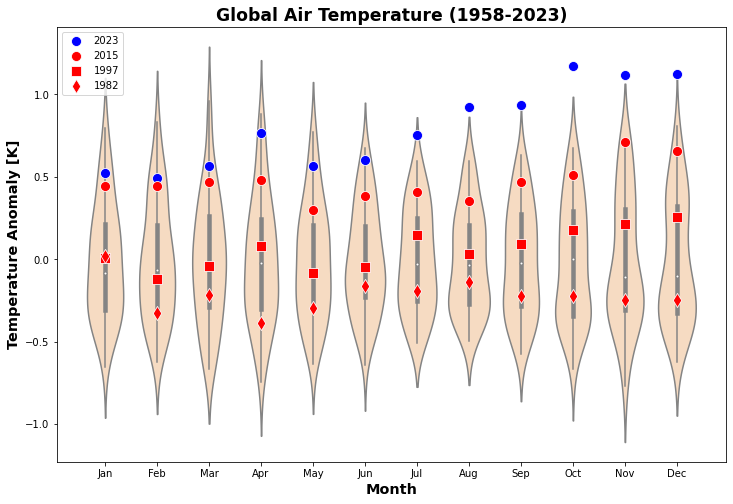

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'peachpuff')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax, zorder = 10, label = '2023')

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax, marker = 'o', zorder = 10, label = '2015')

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax, marker = 's', zorder = 10, label = '1997')


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax, marker = 'd', zorder = 10, label = '1982')

#highlight 2009
#sns.scatterplot(x='month', y='temperature_anomaly', data=df_2009, color='g', s=100, ax=ax, marker = 'd', zorder = 10, label = '2009')




# Customize the plot
ax.set_title('Global Air Temperature (1958-2023)')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature Anomaly [K]')
ax.legend()


"""# Create custom legend
median_patch = mpatches.Patch(color='grey', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')

ax.legend(handles=[median_patch, l2023, lnino], loc='lower center')
"""
#plt.savefig('/data/jmex/output/figures/poster/t2m.svg')
# Show the plot
plt.show()

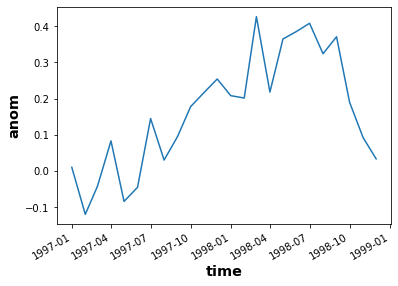

In [18]:
t2m_glbanom.sel(time = slice('1997', '1998')).plot()

## Tropical


In [7]:
#load dataset
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp)


#select rev. time only
t2m = t2m.sel(time = slice('1958-01-01', '2023-12-31'), lat = slice(20,-20))

#compute the mean
t2m_weights = build_weights(t2m, t2m.t2m)
t2m_glbmean = global_mean(t2m, t2m.t2m, t2m_weights)

In [8]:
#compute the anomaly
t2m_glbanom = anomaly(t2m_glbmean, t2m_weights, detrend = False)

In [9]:
df = t2m_glbanom.to_dataframe(name = 'temperature_anomaly')
# Extract year and month from the time index
df['year'] = df.index.year
df['month'] = df.index.month

#
df['month_abbr'] = df['month'].apply(lambda x: calendar.month_abbr[x])


#very strong ensos

# Filter data for the year 2023
df_2023 = df[df['year'] == 2023]

# Filter data for the year 2015
df_2015 = df[df['year'] == 2015]

# Filter data for the year 1997
df_1997 = df[df['year'] == 1997]

# Filter data for the year 1982
df_1982 = df[df['year'] == 1982]

#strong ensos

# Filter data for the year 1987
df_1987 = df[df['year'] == 1987]

# Filter data for the year 1991
df_1991 = df[df['year'] == 1991]


# Filter data for the year 2009
df_2009 = df[df['year'] == 2009]


#filter out year 2023
df = df[df['year']!=2023]

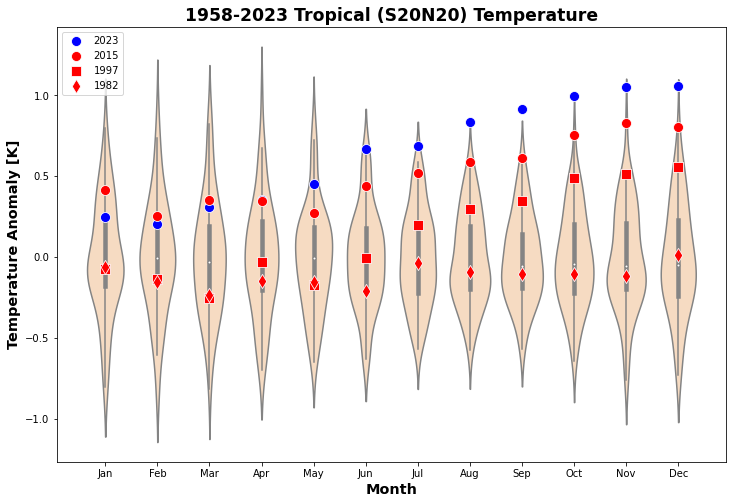

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'peachpuff')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax, zorder = 10, label = '2023')

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax,
                marker = 'o', zorder = 10, label = '2015')

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax,
                marker = 's', zorder = 10, label = '1997')


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax,
                marker = 'd', zorder = 10, label = '1982')

#highlight 2009
#sns.scatterplot(x='month', y='temperature_anomaly', data=df_2009, color='g', s=100, ax=ax, marker = 'd', zorder = 10, label = '2009')

#highlight 1987
#sns.scatterplot(x='month', y='temperature_anomaly', data=df_1987, color='orange', s=100, ax=ax, marker = 's', zorder = 10, label = '1987')

#highlight 1991
#sns.scatterplot(x='month', y='temperature_anomaly', data=df_1991, color='orange', s=100, ax=ax, marker = 'd', zorder = 10, label = '1991')


# Customize the plot
ax.set_title('1958-2023 Tropical (S20N20) Temperature')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature Anomaly [K]')
ax.legend()

"""# Create custom legend
median_patch = mpatches.Patch(color='grey', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')
l2009 = mpatches.Patch(color = 'g', label = '2009')
lstrong = mpatches.Patch(color = 'orange', label = 'Strong ENSO')
ax.legend(handles=[median_patch, l2023, l2009, lnino, lstrong], loc='lower center')


"""
#plt.savefig('/data/jmex/output/figures/poster/t2m.svg')
# Show the plot
plt.show()

## NH


In [34]:
#load dataset
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp)


#select rev. time only
t2m = t2m.sel(time = slice('1958-01-01', '2023-12-31'), lat = slice(-20,-60))

#compute the mean
t2m_weights = build_weights(t2m, t2m.t2m)
t2m_glbmean = global_mean(t2m, t2m.t2m, t2m_weights)

In [35]:
#compute the anomaly
t2m_glbanom = anomaly(t2m_glbmean, t2m_weights, detrend = True)

In [39]:
df = t2m_glbanom.to_dataframe(name = 'temperature_anomaly')
# Extract year and month from the time index
df['year'] = df.index.year
df['month'] = df.index.month

#
df['month_abbr'] = df['month'].apply(lambda x: calendar.month_abbr[x])


# Filter data for the year 2023
df_2023 = df[df['year'] == 2023]

# Filter data for the year 2023
df_2015 = df[df['year'] == 2015]

# Filter data for the year 1997
df_1997 = df[df['year'] == 1997]

# Filter data for the year 1982
df_1982 = df[df['year'] == 1982]


# Filter data for the year 2009
df_2009 = df[df['year'] == 2009]


#filter out year 2023
df = df[df['year']!=2023]

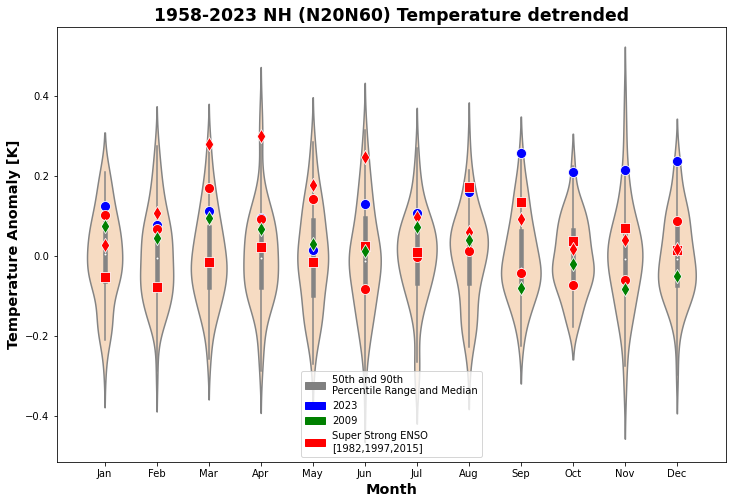

In [40]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'peachpuff')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax, zorder = 10)

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax, marker = 'o', zorder = 10)

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax, marker = 's', zorder = 10)


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax, marker = 'd', zorder = 10)

#highlight 2009
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2009, color='g', s=100, ax=ax, marker = 'd', zorder = 10, label = '2009')




# Customize the plot
ax.set_title('1958-2023 NH (N20N60) Temperature detrended')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature Anomaly [K]')

# Create custom legend
median_patch = mpatches.Patch(color='grey', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')
l2009 = mpatches.Patch(color = 'g', label = '2009')

ax.legend(handles=[median_patch, l2023, l2009, lnino], loc='lower center')
#plt.savefig('/data/jmex/output/figures/poster/t2m.svg')
# Show the plot
plt.show()

# SST

## NA

In [11]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)

#define na_mask as  all of 1.NA SPSS, 2.NA STSS, 3.NA STPS
#after Fay and McKinley 2014
#see https://github.com/RECCAP2-ocean/R2-shared-resources/blob/master/data/regions/README.md

na_mask = masks.atlantic.isin([1,2,3])
indian_mask = masks.open_ocean.isin([3])
pacific_mask = masks.open_ocean.isin([2])
atlantic_mask = masks.open_ocean.isin([1])
southern_mask = masks.open_ocean.isin([5])

In [12]:
#load dataset
fp = '/data/jmex/ERA5/monthly/era5_t2m.nc'
t2m = decode_time(fp)

In [13]:
t2m_noNA = t2m.where(~na_mask)# everything without north atlantic
#t2m_noNA = t2m.where(~na_mask & (masks.seamask==1))# all ocean but na
#t2m_noNA = t2m.where(masks.seamask ==0)# all ocean but na





In [14]:
#select rev. time only
t2m_noNA = t2m_noNA.sel(time = slice('1958-01-01', '2023-12-31'), )

#compute the mean
t2m_weights = build_weights(t2m_noNA, t2m_noNA.t2m)
t2m_glbmean = global_mean(t2m_noNA, t2m_noNA.t2m, t2m_weights)

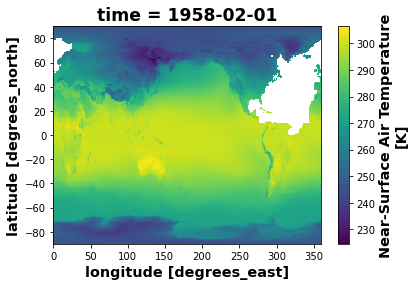

In [15]:
t2m_noNA.isel(time = 1).t2m.plot()

In [16]:
#compute the anomaly
t2m_glbanom = anomaly(t2m_glbmean, t2m_weights, detrend = False)

In [17]:
df = t2m_glbanom.to_dataframe(name = 'temperature_anomaly')
# Extract year and month from the time index
df['year'] = df.index.year
df['month'] = df.index.month

#
df['month_abbr'] = df['month'].apply(lambda x: calendar.month_abbr[x])


#very strong ensos

# Filter data for the year 2023
df_2023 = df[df['year'] == 2023]

# Filter data for the year 2015
df_2015 = df[df['year'] == 2015]

# Filter data for the year 1997
df_1997 = df[df['year'] == 1997]

# Filter data for the year 1982
df_1982 = df[df['year'] == 1982]

#strong ensos

# Filter data for the year 1987
df_1987 = df[df['year'] == 1987]

# Filter data for the year 1991
df_1991 = df[df['year'] == 1991]


# Filter data for the year 2009
df_2009 = df[df['year'] == 2009]


#filter out year 2023
df = df[df['year']!=2023]

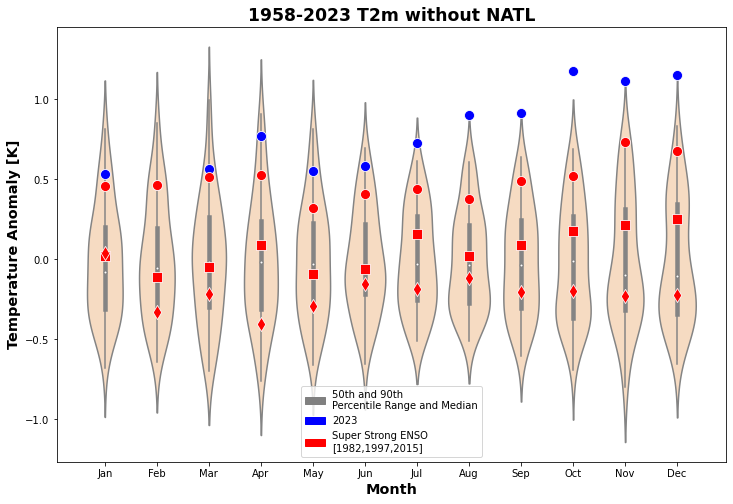

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'peachpuff')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax,
                zorder = 10, label = '2023')

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax,
                marker = 'o', zorder = 10, label = '2015')

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax,
                marker = 's', zorder = 10, label = '199')


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax,
                marker = 'd', zorder = 10)
"""
#highlight 2009
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2009, color='g', s=100, ax=ax, marker = 'd', zorder = 10, label = '2009')

#highlight 1987
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1987, color='orange', s=100, ax=ax, marker = 's', zorder = 10, label = '1987')

#highlight 1991
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1991, color='orange', s=100, ax=ax, marker = 'd', zorder = 10, label = '1991')
"""

# Customize the plot
ax.set_title('1958-2023 T2m without NATL')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature Anomaly [K]')

# Create custom legend
median_patch = mpatches.Patch(color='grey', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')
#l2009 = mpatches.Patch(color = 'g', label = '2009')
lstrong = mpatches.Patch(color = 'orange', label = 'Strong ENSO')


ax.legend(handles=[median_patch, l2023, lnino], loc='lower center')
#plt.savefig('/data/jmex/output/figures/poster/t2m.svg')
# Show the plot
plt.show()

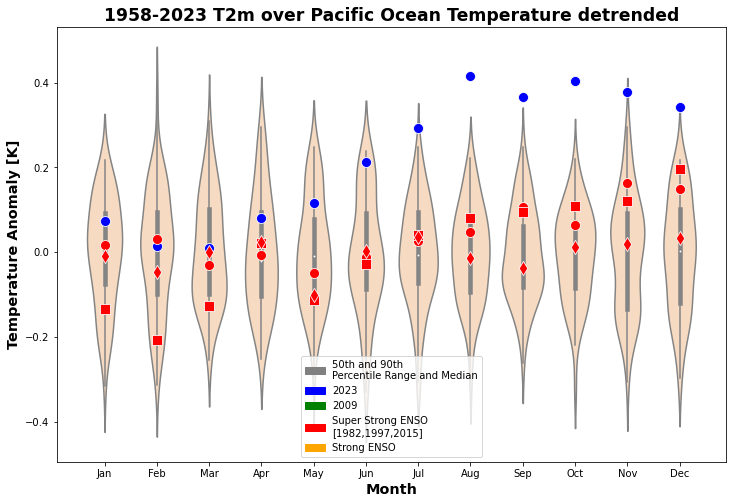

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'peachpuff')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax, zorder = 10)

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax, marker = 'o', zorder = 10)

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax, marker = 's', zorder = 10)


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax, marker = 'd', zorder = 10)
"""
#highlight 2009
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2009, color='g', s=100, ax=ax, marker = 'd', zorder = 10, label = '2009')

#highlight 1987
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1987, color='orange', s=100, ax=ax, marker = 's', zorder = 10, label = '1987')

#highlight 1991
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1991, color='orange', s=100, ax=ax, marker = 'd', zorder = 10, label = '1991')
"""

# Customize the plot
ax.set_title('1958-2023 T2m over Pacific Ocean Temperature detrended')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature Anomaly [K]')

# Create custom legend
median_patch = mpatches.Patch(color='grey', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')
l2009 = mpatches.Patch(color = 'g', label = '2009')
lstrong = mpatches.Patch(color = 'orange', label = 'Strong ENSO')


ax.legend(handles=[median_patch, l2023, l2009, lnino, lstrong], loc='lower center')
#plt.savefig('/data/jmex/output/figures/poster/t2m.svg')
# Show the plot
plt.show()

In [36]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)


#select revtime only
#select box area
sst = sst.sel(time = slice('1997-01-01', '2023-12-31'))
na_sst = sst.where(~na_mask)


na_sst_weights = build_weights(na_sst, na_sst.sst)
na_sst_glbmean = global_mean(na_sst, na_sst.sst, na_sst_weights)

In [37]:
na_sst_glbanom = anomaly(na_sst_glbmean, na_sst_weights, detrend = True)


In [38]:
df = na_sst_glbanom.to_dataframe(name = 'temperature_anomaly')
# Extract year and month from the time index
df['year'] = df.index.year
df['month'] = df.index.month

#
df['month_abbr'] = df['month'].apply(lambda x: calendar.month_abbr[x])


# Filter data for the year 2023
df_2023 = df[df['year'] == 2023]

# Filter data for the year 2023
df_2015 = df[df['year'] == 2015]

# Filter data for the year 1997
df_1997 = df[df['year'] == 1997]

# Filter data for the year 1982
df_1982 = df[df['year'] == 1982]



#filter out year 2023
df = df[df['year']!=2023]

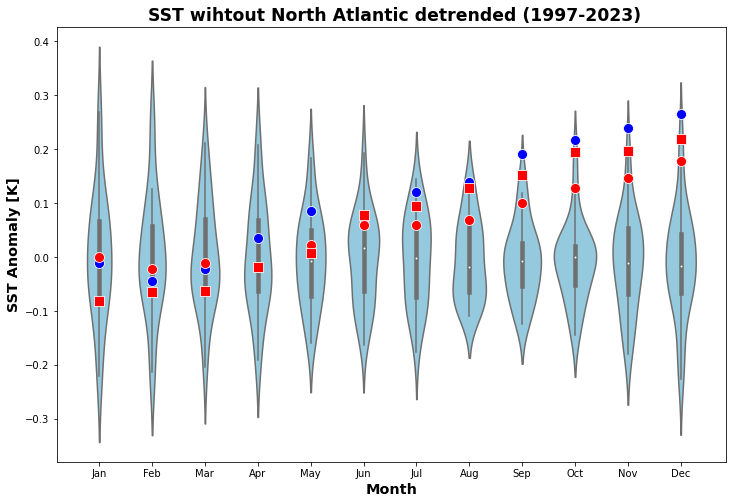

In [40]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'skyblue')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax, zorder = 10)

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax, marker = 'o', zorder = 10)

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax, marker = 's', zorder = 10)


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax, marker = 'd', zorder = 10)


# Customize the plot
ax.set_title(' SST wihtout North Atlantic detrended (1997-2023)')
ax.set_xlabel('Month')
ax.set_ylabel('SST Anomaly [K]')

# Create custom legend
median_patch = mpatches.Patch(color='k', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')

#ax.legend(handles=[median_patch, l2023, lnino], loc='lower center')
#plt.savefig('/data/jmex/output/figures/poster/dt_nasst.svg')

# Show the plot
plt.show()

## Other 

In [9]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)#select rev. time only
#select revtime only
#select box area
sst = sst.sel(time = slice('1958-01-01', '2023-12-31'))


na_sst = sst.where(pacific_mask).sel(lat = slice(60,20))


na_sst_weights = build_weights(na_sst, na_sst.sst)
na_sst_glbmean = global_mean(na_sst, na_sst.sst, na_sst_weights)

In [10]:
na_sst_glbanom = anomaly(na_sst_glbmean, na_sst_weights, detrend = True)


In [13]:
df = na_sst_glbanom.to_dataframe(name = 'temperature_anomaly')
# Extract year and month from the time index
df['year'] = df.index.year
df['month'] = df.index.month

#
df['month_abbr'] = df['month'].apply(lambda x: calendar.month_abbr[x])


# Filter data for the year 2023
df_2023 = df[df['year'] == 2023]

# Filter data for the year 2023
df_2015 = df[df['year'] == 2015]

# Filter data for the year 1997
df_1997 = df[df['year'] == 1997]

# Filter data for the year 1982
df_1982 = df[df['year'] == 1982]


# Filter data for the year 1982
df_2009 = df[df['year'] == 2009]


#filter out year 2023
df = df[df['year']!=2023]

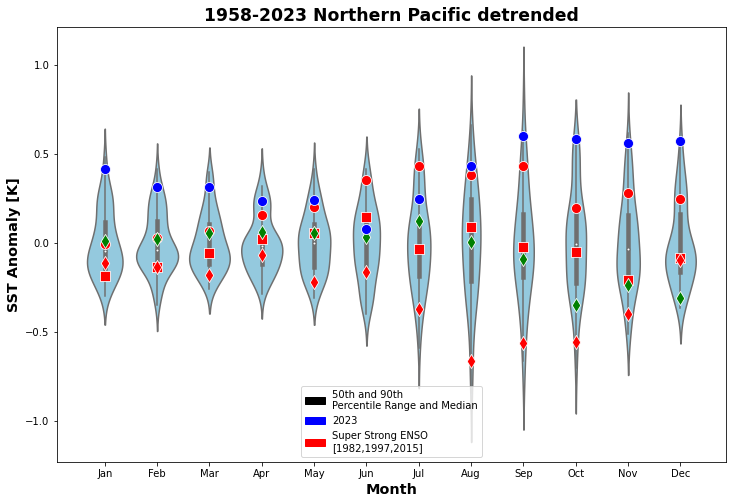

In [14]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create a violin plot using seaborn
sns.violinplot(x='month_abbr', y='temperature_anomaly', data=df, 
               ax=ax, 
               inner_kws=dict(box_width=55, whis_width=2, color="1"),
               quantiles=[0.5, 0.9],
               order=calendar.month_abbr, color = 'skyblue')

# Highlight points for the year 2023 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2023, color='b', s=100, ax=ax, zorder = 20)

# Highlight points for the year 2015 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2015, color='r', s=100, ax=ax, marker = 'o', zorder = 10)

# Highlight points for the year 1997 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1997, color='r', s=100, ax=ax, marker = 's', zorder = 10)


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_1982, color='r', s=100, ax=ax, marker = 'd', zorder = 10)


# Highlight points for the year 1982 using scatter plot
sns.scatterplot(x='month', y='temperature_anomaly', data=df_2009, color='g', s=100, ax=ax, marker = 'd', zorder = 10)


strong_ninos = [1965, 1972,1987, 1991]
#highlight strong el ninos: 
#for y in strong_ninos:
 #   sns.lineplot(x='month', y='temperature_anomaly', data=df[df['year']==y], color='orange', ax=ax, marker = 'd', zorder = 5)

#central pacific nino
#sns.lineplot(x='month', y='temperature_anomaly', data=df[df['year']==2009], color='green', ax=ax, marker = 'd', zorder = 5)

    

# Customize the plot
ax.set_title('1958-2023 Northern Pacific detrended')
ax.set_xlabel('Month')
ax.set_ylabel('SST Anomaly [K]')

# Create custom legend
median_patch = mpatches.Patch(color='k', label='50th and 90th \nPercentile Range and Median')
l2023 = mpatches.Patch(color='b', label='2023')
lnino = mpatches.Patch(color='r', label='Super Strong ENSO \n[1982,1997,2015]')

ax.legend(handles=[median_patch, l2023, lnino], loc='lower center')
plt.savefig('/data/jmex/output/figures/monthly_var/dt_NPsst.svg')

# Show the plot
plt.show()